In [2]:
# Chinook Database Analysis Project
# SQL in Data Science with Python

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("=" * 60)
print("CHINOOK DATABASE ANALYSIS PROJECT")
print("=" * 60)

Matplotlib is building the font cache; this may take a moment.


CHINOOK DATABASE ANALYSIS PROJECT


In [3]:
# Download the Chinook database (if not already downloaded)
import urllib.request
import os

db_file = "chinook.db"
if not os.path.exists(db_file):
    print("Downloading Chinook database...")
    url = "https://github.com/lerocha/chinook-database/raw/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite"
    urllib.request.urlretrieve(url, db_file)
    print("Download complete!")

# Connect to the database
conn = sqlite3.connect(db_file)
cursor = conn.cursor()
print("Connected to Chinook database successfully!")

Download complete!
Connected to Chinook database successfully!


In [4]:
# Get all tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Tables in the database:")
for table in tables:
    print(f"  - {table[0]}")

# Explore schema of each table
print("\n" + "="*60)
print("TABLE SCHEMAS:")
print("="*60)

for table in tables:
    table_name = table[0]
    cursor.execute(f"PRAGMA table_info({table_name});")
    columns = cursor.fetchall()
    print(f"\nTable: {table_name}")
    print(f"{'Column':<25} {'Type':<15} {'Nullable'} {'PK'}")
    print("-" * 55)
    for col in columns:
        pk = "✓" if col[5] == 1 else ""
        print(f"{col[1]:<25} {col[2]:<15} {col[3]} {pk}")

Tables in the database:
  - Album
  - Artist
  - Customer
  - Employee
  - Genre
  - Invoice
  - InvoiceLine
  - MediaType
  - Playlist
  - PlaylistTrack
  - Track

TABLE SCHEMAS:

Table: Album
Column                    Type            Nullable PK
-------------------------------------------------------
AlbumId                   INTEGER         1 ✓
Title                     NVARCHAR(160)   1 
ArtistId                  INTEGER         1 

Table: Artist
Column                    Type            Nullable PK
-------------------------------------------------------
ArtistId                  INTEGER         1 ✓
Name                      NVARCHAR(120)   0 

Table: Customer
Column                    Type            Nullable PK
-------------------------------------------------------
CustomerId                INTEGER         1 ✓
FirstName                 NVARCHAR(40)    1 
LastName                  NVARCHAR(20)    1 
Company                   NVARCHAR(80)    0 
Address                   NVARCHAR(7

In [5]:
# Analyze relationships by looking at foreign keys
print("\n" + "="*60)
print("TABLE RELATIONSHIPS:")
print("="*60)

# Look at key tables and their relationships
tables_of_interest = ['Album', 'Artist', 'Customer', 'Employee', 'Genre', 
                      'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 
                      'PlaylistTrack', 'Track']

# Sample data from main tables to understand structure
print("\nSample data from main tables:")
main_tables = ['Artist', 'Album', 'Track', 'Genre', 'MediaType', 'Customer', 'Employee', 'Invoice', 'InvoiceLine']

for table in main_tables:
    df_sample = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 3;", conn)
    print(f"\n{table}:")
    print(df_sample.columns.tolist())
    print(f"Row count: {len(pd.read_sql_query(f'SELECT * FROM {table};', conn))}")


TABLE RELATIONSHIPS:

Sample data from main tables:

Artist:
['ArtistId', 'Name']
Row count: 275

Album:
['AlbumId', 'Title', 'ArtistId']
Row count: 347

Track:
['TrackId', 'Name', 'AlbumId', 'MediaTypeId', 'GenreId', 'Composer', 'Milliseconds', 'Bytes', 'UnitPrice']
Row count: 3503

Genre:
['GenreId', 'Name']
Row count: 25

MediaType:
['MediaTypeId', 'Name']
Row count: 5

Customer:
['CustomerId', 'FirstName', 'LastName', 'Company', 'Address', 'City', 'State', 'Country', 'PostalCode', 'Phone', 'Fax', 'Email', 'SupportRepId']
Row count: 59

Employee:
['EmployeeId', 'LastName', 'FirstName', 'Title', 'ReportsTo', 'BirthDate', 'HireDate', 'Address', 'City', 'State', 'Country', 'PostalCode', 'Phone', 'Fax', 'Email']
Row count: 8

Invoice:
['InvoiceId', 'CustomerId', 'InvoiceDate', 'BillingAddress', 'BillingCity', 'BillingState', 'BillingCountry', 'BillingPostalCode', 'Total']
Row count: 412

InvoiceLine:
['InvoiceLineId', 'InvoiceId', 'TrackId', 'UnitPrice', 'Quantity']
Row count: 2240


In [6]:
# Which are the 10 best-selling tracks?
query_best_tracks = """
SELECT 
    t.Name AS TrackName,
    a.Title AS AlbumTitle,
    ar.Name AS ArtistName,
    COUNT(il.InvoiceLineId) AS NumberOfPurchases,
    SUM(il.UnitPrice) AS TotalRevenue
FROM Track t
JOIN Album a ON t.AlbumId = a.AlbumId
JOIN Artist ar ON a.ArtistId = ar.ArtistId
JOIN InvoiceLine il ON t.TrackId = il.TrackId
GROUP BY t.TrackId, t.Name, a.Title, ar.Name
ORDER BY NumberOfPurchases DESC
LIMIT 10;
"""

best_tracks = pd.read_sql_query(query_best_tracks, conn)
print("\n" + "="*60)
print("10 BEST-SELLING TRACKS:")
print("="*60)
print(best_tracks.to_string(index=False))


10 BEST-SELLING TRACKS:
                TrackName                            AlbumTitle           ArtistName  NumberOfPurchases  TotalRevenue
        Balls to the Wall                     Balls to the Wall               Accept                  2          1.98
         Inject The Venom For Those About To Rock We Salute You                AC/DC                  2          1.98
               Snowballed For Those About To Rock We Salute You                AC/DC                  2          1.98
                 Overdose                     Let There Be Rock                AC/DC                  2          1.98
          Deuces Are Wild                              Big Ones            Aerosmith                  2          1.98
           Not The Doctor                    Jagged Little Pill    Alanis Morissette                  2          1.98
        Por Causa De Você                        Warner 25 Anos Antônio Carlos Jobim                  2          1.98
Welcome Home (Sanitarium)      

In [7]:
# Which country generates the most revenue?
query_revenue_by_country = """
SELECT 
    i.BillingCountry AS Country,
    COUNT(DISTINCT i.InvoiceId) AS NumberOfInvoices,
    COUNT(i.InvoiceId) AS TotalTransactions,
    SUM(i.Total) AS TotalRevenue,
    ROUND(AVG(i.Total), 2) AS AverageInvoiceValue
FROM Invoice i
GROUP BY i.BillingCountry
ORDER BY TotalRevenue DESC;
"""

revenue_by_country = pd.read_sql_query(query_revenue_by_country, conn)
print("\n" + "="*60)
print("REVENUE BY COUNTRY:")
print("="*60)
print(revenue_by_country.to_string(index=False))

# Top country
top_country = revenue_by_country.iloc[0]
print(f"\n🏆 Top Revenue Country: {top_country['Country']}")
print(f"   Total Revenue: ${top_country['TotalRevenue']:.2f}")
print(f"   Number of Invoices: {top_country['NumberOfInvoices']}")


REVENUE BY COUNTRY:
       Country  NumberOfInvoices  TotalTransactions  TotalRevenue  AverageInvoiceValue
           USA                91                 91        523.06                 5.75
        Canada                56                 56        303.96                 5.43
        France                35                 35        195.10                 5.57
        Brazil                35                 35        190.10                 5.43
       Germany                28                 28        156.48                 5.59
United Kingdom                21                 21        112.86                 5.37
Czech Republic                14                 14         90.24                 6.45
      Portugal                14                 14         77.24                 5.52
         India                13                 13         75.26                 5.79
         Chile                 7                  7         46.62                 6.66
       Ireland        

In [8]:
# Who is the top-performing sales employee?
query_top_employee = """
SELECT 
    e.EmployeeId,
    e.FirstName || ' ' || e.LastName AS EmployeeName,
    e.Title,
    COUNT(DISTINCT c.CustomerId) AS NumberOfCustomers,
    COUNT(i.InvoiceId) AS NumberOfSales,
    SUM(i.Total) AS TotalRevenue,
    ROUND(AVG(i.Total), 2) AS AverageSaleValue
FROM Employee e
JOIN Customer c ON e.EmployeeId = c.SupportRepId
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY e.EmployeeId, e.FirstName, e.LastName, e.Title
ORDER BY TotalRevenue DESC;
"""

top_employee = pd.read_sql_query(query_top_employee, conn)
print("\n" + "="*60)
print("TOP PERFORMING SALES EMPLOYEES:")
print("="*60)
print(top_employee.to_string(index=False))

# Top employee
top_emp = top_employee.iloc[0]
print(f"\n🏆 Top Sales Employee: {top_emp['EmployeeName']}")
print(f"   Title: {top_emp['Title']}")
print(f"   Total Revenue: ${top_emp['TotalRevenue']:.2f}")
print(f"   Number of Customers: {top_emp['NumberOfCustomers']}")


TOP PERFORMING SALES EMPLOYEES:
 EmployeeId  EmployeeName               Title  NumberOfCustomers  NumberOfSales  TotalRevenue  AverageSaleValue
          3  Jane Peacock Sales Support Agent                 21            146        833.04              5.71
          4 Margaret Park Sales Support Agent                 20            140        775.40              5.54
          5 Steve Johnson Sales Support Agent                 18            126        720.16              5.72

🏆 Top Sales Employee: Jane Peacock
   Title: Sales Support Agent
   Total Revenue: $833.04
   Number of Customers: 21


In [9]:
# Track popularity by genre
query_track_by_genre = """
SELECT 
    g.Name AS Genre,
    COUNT(il.InvoiceLineId) AS NumberOfSales,
    COUNT(DISTINCT t.TrackId) AS UniqueTracks,
    SUM(il.UnitPrice) AS TotalRevenue
FROM Genre g
JOIN Track t ON g.GenreId = t.GenreId
JOIN InvoiceLine il ON t.TrackId = il.TrackId
GROUP BY g.GenreId, g.Name
ORDER BY NumberOfSales DESC
LIMIT 10;
"""

genre_sales = pd.read_sql_query(query_track_by_genre, conn)
print("\n" + "="*60)
print("TOP 10 GENRES BY SALES:")
print("="*60)
print(genre_sales.to_string(index=False))

# Monthly revenue trend
query_monthly_revenue = """
SELECT 
    strftime('%Y-%m', InvoiceDate) AS Month,
    COUNT(InvoiceId) AS InvoiceCount,
    SUM(Total) AS TotalRevenue,
    ROUND(AVG(Total), 2) AS AverageInvoice
FROM Invoice
GROUP BY strftime('%Y-%m', InvoiceDate)
ORDER BY Month;
"""

monthly_revenue = pd.read_sql_query(query_monthly_revenue, conn)
print("\n" + "="*60)
print("MONTHLY REVENUE TREND:")
print("="*60)
print(monthly_revenue.to_string(index=False))


TOP 10 GENRES BY SALES:
             Genre  NumberOfSales  UniqueTracks  TotalRevenue
              Rock            835           745        826.65
             Latin            386           340        382.14
             Metal            264           231        261.36
Alternative & Punk            244           203        241.56
              Jazz             80            68         79.20
             Blues             61            53         60.39
          TV Shows             47            43         93.53
          R&B/Soul             41            37         40.59
         Classical             41            36         40.59
            Reggae             30            28         29.70

MONTHLY REVENUE TREND:
  Month  InvoiceCount  TotalRevenue  AverageInvoice
2021-01             6         35.64            5.94
2021-02             7         37.62            5.37
2021-03             7         37.62            5.37
2021-04             7         37.62            5.37
2021-05  

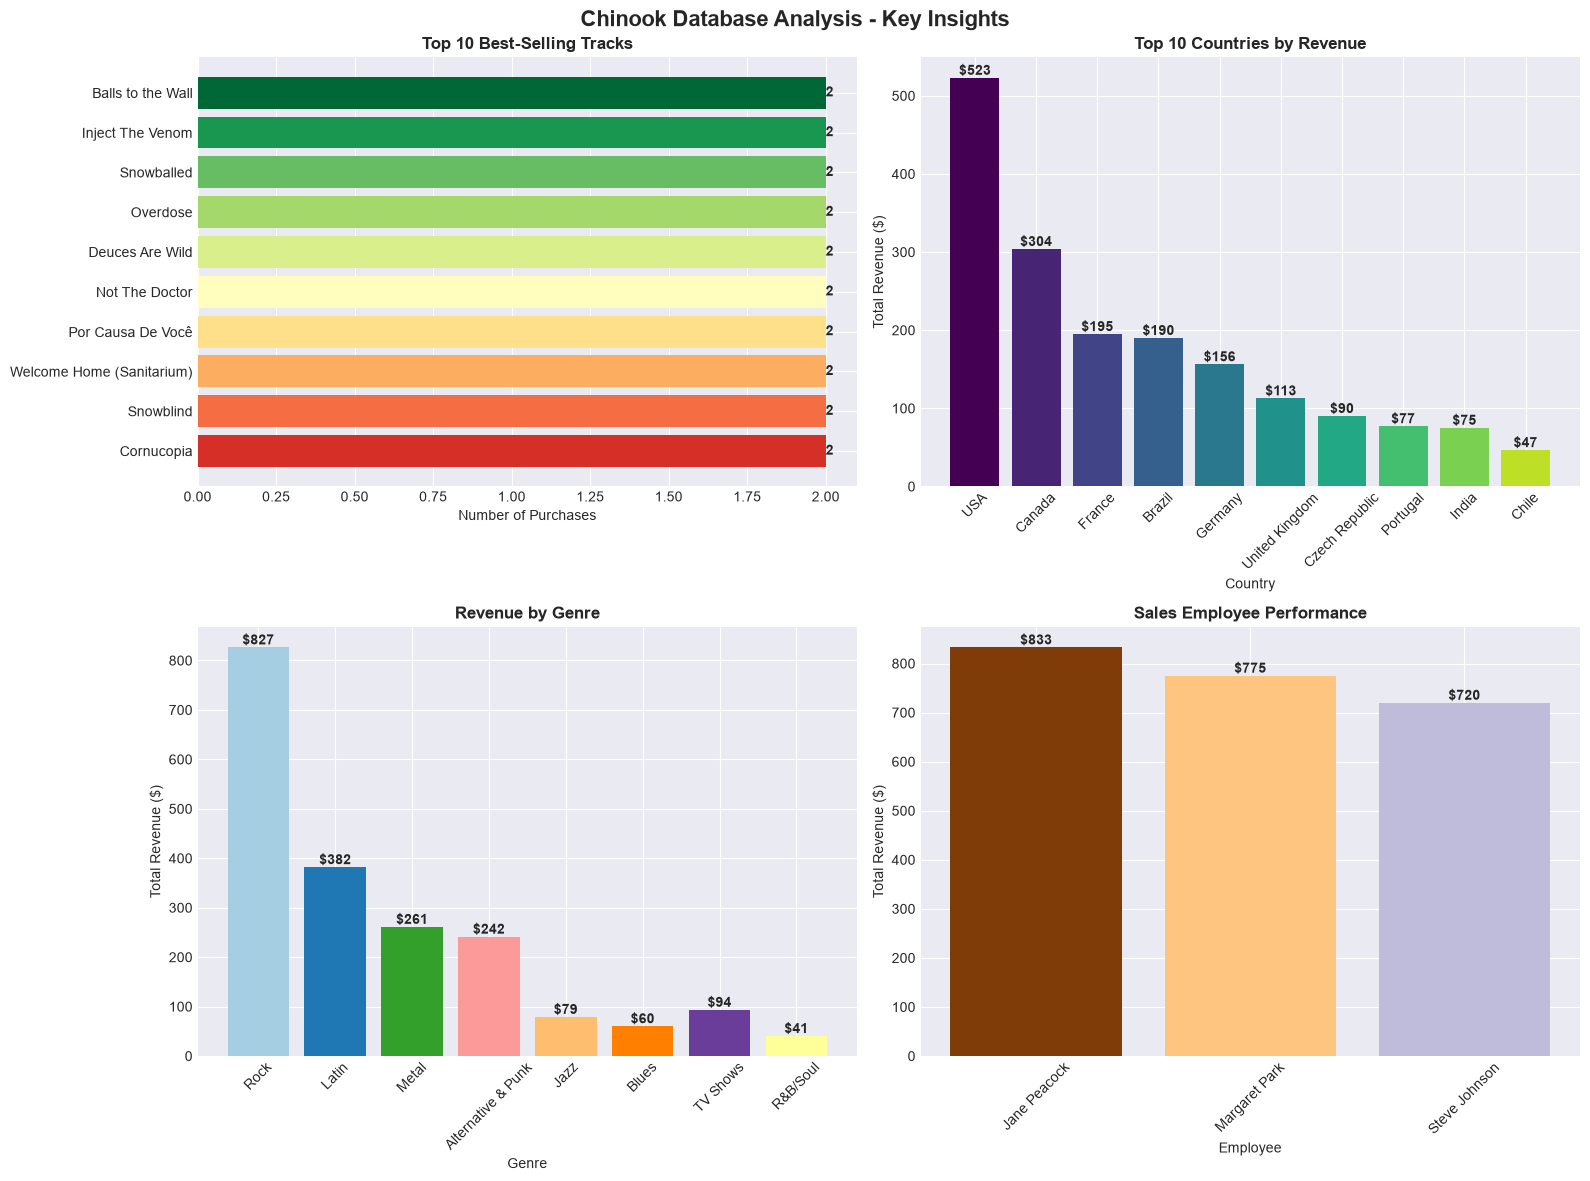

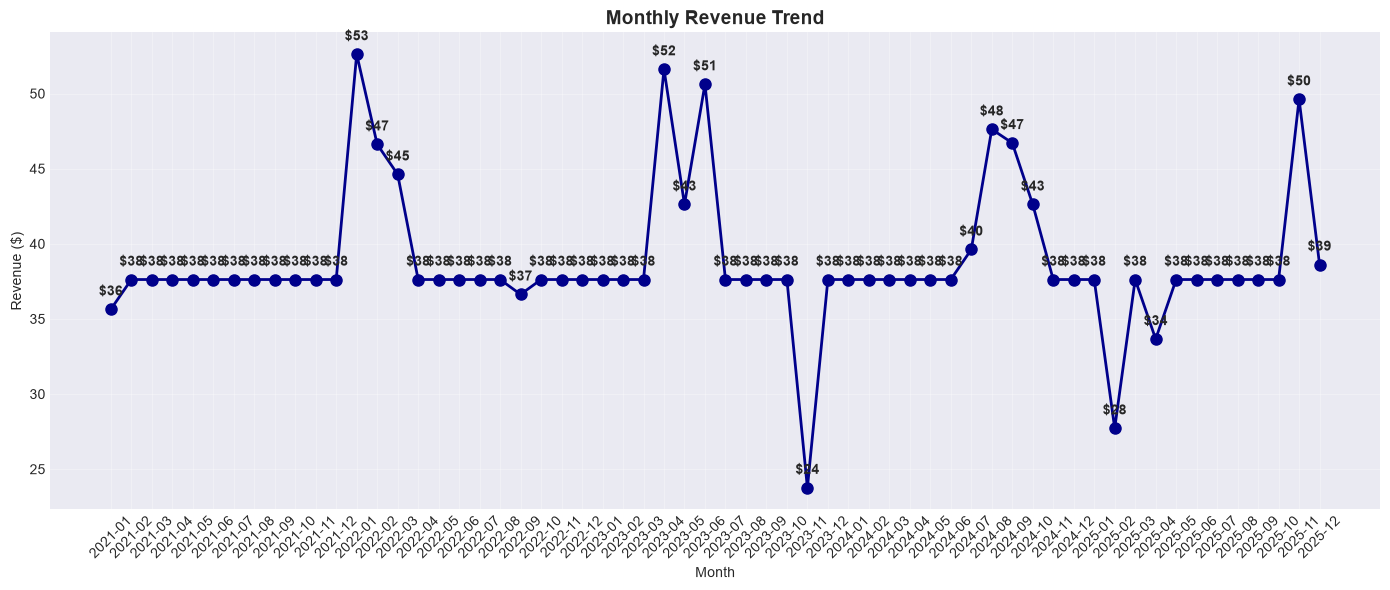

In [10]:
# Set up visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Chinook Database Analysis - Key Insights', fontsize=16, fontweight='bold')

# 1. Best Selling Tracks
ax1 = axes[0, 0]
colors = plt.cm.RdYlGn_r([i/len(best_tracks) for i in range(len(best_tracks))])
bars = ax1.barh(best_tracks['TrackName'][:10], best_tracks['NumberOfPurchases'][:10], color=colors)
ax1.set_xlabel('Number of Purchases')
ax1.set_title('Top 10 Best-Selling Tracks', fontweight='bold')
ax1.invert_yaxis()
# Add value labels
for i, bar in enumerate(bars):
    ax1.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
             f'{int(bar.get_width())}', ha='left', va='center', fontweight='bold')

# 2. Revenue by Country (Top 10)
ax2 = axes[0, 1]
top_countries = revenue_by_country.head(10)
colors = plt.cm.viridis([i/len(top_countries) for i in range(len(top_countries))])
bars2 = ax2.bar(top_countries['Country'], top_countries['TotalRevenue'], color=colors)
ax2.set_xlabel('Country')
ax2.set_ylabel('Total Revenue ($)')
ax2.set_title('Top 10 Countries by Revenue', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
# Add value labels
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:.0f}', ha='center', va='bottom', fontweight='bold')

# 3. Revenue by Genre
ax3 = axes[1, 0]
genre_data = genre_sales.head(8)
colors = plt.cm.Paired([i/len(genre_data) for i in range(len(genre_data))])
bars3 = ax3.bar(genre_data['Genre'], genre_data['TotalRevenue'], color=colors)
ax3.set_xlabel('Genre')
ax3.set_ylabel('Total Revenue ($)')
ax3.set_title('Revenue by Genre', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
# Add value labels
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:.0f}', ha='center', va='bottom', fontweight='bold')

# 4. Employee Performance
ax4 = axes[1, 1]
employee_data = top_employee
colors = plt.cm.PuOr([i/len(employee_data) for i in range(len(employee_data))])
bars4 = ax4.bar(employee_data['EmployeeName'], employee_data['TotalRevenue'], color=colors)
ax4.set_xlabel('Employee')
ax4.set_ylabel('Total Revenue ($)')
ax4.set_title('Sales Employee Performance', fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
# Add value labels
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Additional visualization: Monthly Revenue Trend
plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['Month'], monthly_revenue['TotalRevenue'], 
         marker='o', linewidth=2, markersize=8, color='darkblue')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
for i, row in monthly_revenue.iterrows():
    plt.annotate(f'${row["TotalRevenue"]:.0f}', 
                 (row['Month'], row['TotalRevenue']),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center',
                 fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
print("\n" + "="*60)
print("ADDITIONAL INSIGHTS:")
print("="*60)

# Customer lifetime value
query_clv = """
SELECT 
    c.CustomerId,
    c.FirstName || ' ' || c.LastName AS CustomerName,
    c.Country,
    COUNT(i.InvoiceId) AS NumberOfPurchases,
    SUM(i.Total) AS TotalSpent,
    ROUND(AVG(i.Total), 2) AS AveragePurchaseValue,
    MAX(i.InvoiceDate) AS LastPurchaseDate,
    CASE 
        WHEN julianday('now') - julianday(MAX(i.InvoiceDate)) > 365 THEN 'Churned'
        WHEN julianday('now') - julianday(MAX(i.InvoiceDate)) > 180 THEN 'At Risk'
        ELSE 'Active'
    END AS CustomerStatus
FROM Customer c
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId, c.FirstName, c.LastName, c.Country
ORDER BY TotalSpent DESC
LIMIT 20;
"""

customer_clv = pd.read_sql_query(query_clv, conn)
print("\nTop 20 Customers by Lifetime Value:")
print(customer_clv.to_string(index=False))

# Product mix analysis
query_product_mix = """
SELECT 
    g.Name AS Genre,
    m.Name AS MediaType,
    COUNT(il.InvoiceLineId) AS SalesCount,
    SUM(il.UnitPrice) AS Revenue,
    ROUND(AVG(t.Milliseconds/60000.0), 2) AS AvgDurationMinutes
FROM Genre g
JOIN Track t ON g.GenreId = t.GenreId
JOIN MediaType m ON t.MediaTypeId = m.MediaTypeId
JOIN InvoiceLine il ON t.TrackId = il.TrackId
GROUP BY g.GenreId, g.Name, m.MediaTypeId, m.Name
ORDER BY Revenue DESC
LIMIT 15;
"""

product_mix = pd.read_sql_query(query_product_mix, conn)
print("\nProduct Mix Analysis (Top 15):")
print(product_mix.to_string(index=False))


ADDITIONAL INSIGHTS:

Top 20 Customers by Lifetime Value:
 CustomerId          CustomerName        Country  NumberOfPurchases  TotalSpent  AveragePurchaseValue    LastPurchaseDate CustomerStatus
          6           Helena Holý Czech Republic                  7       49.62                  7.09 2025-11-13 00:00:00        At Risk
         26    Richard Cunningham            USA                  7       47.62                  6.80 2025-04-05 00:00:00        Churned
         57            Luis Rojas          Chile                  7       46.62                  6.66 2024-10-14 00:00:00        Churned
         45       Ladislav Kovács        Hungary                  7       45.62                  6.52 2025-07-20 00:00:00        Churned
         46         Hugh O'Reilly        Ireland                  7       45.62                  6.52 2025-11-04 00:00:00        At Risk
         24         Frank Ralston            USA                  7       43.62                  6.23 2025-08-20 00:00:

In [12]:
# Export all results to CSV files
import os

# Create exports directory
os.makedirs('exports', exist_ok=True)

# Export all dataframes
best_tracks.to_csv('exports/best_selling_tracks.csv', index=False)
revenue_by_country.to_csv('exports/revenue_by_country.csv', index=False)
top_employee.to_csv('exports/top_employees.csv', index=False)
genre_sales.to_csv('exports/genre_sales.csv', index=False)
monthly_revenue.to_csv('exports/monthly_revenue.csv', index=False)
customer_clv.to_csv('exports/customer_lifetime_value.csv', index=False)

print("\n✅ All results exported to 'exports' directory")

# Summary statistics
print("\n" + "="*60)
print("PROJECT SUMMARY STATISTICS:")
print("="*60)
print(f"Total Revenue Generated: ${pd.read_sql_query('SELECT SUM(Total) FROM Invoice;', conn).iloc[0,0]:.2f}")
print(f"Total Customers: {pd.read_sql_query('SELECT COUNT(*) FROM Customer;', conn).iloc[0,0]}")
print(f"Total Tracks Sold: {pd.read_sql_query('SELECT COUNT(*) FROM InvoiceLine;', conn).iloc[0,0]}")
print(f"Total Invoices: {pd.read_sql_query('SELECT COUNT(*) FROM Invoice;', conn).iloc[0,0]}")


✅ All results exported to 'exports' directory

PROJECT SUMMARY STATISTICS:
Total Revenue Generated: $2328.60
Total Customers: 59
Total Tracks Sold: 2240
Total Invoices: 412


In [13]:
# Close the database connection
conn.close()
print("\n🔌 Database connection closed successfully!")
print("✅ Project completed successfully!")
print("="*60)


🔌 Database connection closed successfully!
✅ Project completed successfully!
